##### Part 1 EDA

In [128]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
import matplotlib.dates as mdates


In [48]:
#import as dictionary
with open('../logins.json', 'r') as f:
    logins = json.load(f)
logins.keys()

dict_keys(['login_time'])

In [49]:
#load pandas dataframe

logins_df = pd.DataFrame(logins)

In [50]:
logins_df.head()

,login_time
0,1970-01-01 20:13:18
1,1970-01-01 20:16:10
2,1970-01-01 20:16:37
3,1970-01-01 20:16:36
4,1970-01-01 20:26:21


In [51]:
#convert to datetime
logins_df['login_time'] = pd.to_datetime(logins_df['login_time'])

In [52]:
logins_df.shape


(93142, 1)

In [53]:
logins_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 93142 entries, 0 to 93141
Data columns (total 1 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   login_time  93142 non-null  datetime64[ns]
dtypes: datetime64[ns](1)
memory usage: 727.8 KB


In [54]:
logins_df.isnull().sum()

login_time    0
dtype: int64

In [55]:
# rounding values to 15 min intervals with function
from datetime import datetime, timedelta

def round_time_to_15_minutes(dt):
    # Calculate how many minutes past the nearest 15-minute mark
    minutes_past = dt.minute % 15
    
    # Round down if less than 7.5 minutes past the mark
    if minutes_past < 7.5:
        correction_minutes = -minutes_past
    # Round up if more than or equal to 7.5 minutes past
    else:
        correction_minutes = 15 - minutes_past
    
    # Apply the correction and reset seconds and microseconds
    return (dt + timedelta(minutes=correction_minutes)).replace(second=0, microsecond=0)

In [ ]:
#rounding times to nearest 15 minutes
logins_df['login_time_rounded'] = logins_df['login_time'].apply(round_time_to_15_minutes)

In [57]:
logins_df.drop(columns=['login_time'], inplace=True)
logins_df.head()

,login_time_rounded
0,1970-01-01 20:15:00
1,1970-01-01 20:15:00
2,1970-01-01 20:15:00
3,1970-01-01 20:15:00
4,1970-01-01 20:30:00


In [ ]:
# group logins with same values
logins_df['total_logins'] = logins_df.groupby('login_time_rounded')['login_time_rounded'].transform('count')

In [63]:
logins_df.head(20)

,login_time_rounded,total_logins
0,1970-01-01 20:15:00,6
1,1970-01-01 20:15:00,6
2,1970-01-01 20:15:00,6
3,1970-01-01 20:15:00,6
4,1970-01-01 20:30:00,8
5,1970-01-01 20:15:00,6
6,1970-01-01 20:15:00,6
7,1970-01-01 20:30:00,8
8,1970-01-01 20:30:00,8
9,1970-01-01 20:45:00,7


In [113]:
#dropping duplicate login times
logins_df1 = logins_df.groupby('login_time_rounded')['total_logins'].first().reset_index()
logins_df1 = logins_df1.sort_values(by='login_time_rounded')
logins_df1.head()

,login_time_rounded,total_logins
0,1970-01-01 20:15:00,6
1,1970-01-01 20:30:00,8
2,1970-01-01 20:45:00,7
3,1970-01-01 21:00:00,3
4,1970-01-01 21:15:00,4


In [ ]:
# Create a column for just the time of day
logins_df1['time_of_day'] = logins_df1['login_time_rounded'].dt.time
# create a column for just the month
logins_df1['month'] = logins_df1['login_time_rounded'].dt.month
# create a column for just the day
logins_df1['day'] = logins_df1['login_time_rounded'].dt.day
# the data is only from 1970 so we do not need a year column
# the data is only from month 1 to 4


In [120]:
logins_df1['time_of_day'] = pd.to_datetime(logins_df1['time_of_day'], format='%H:%M:%S')


In [121]:
logins_df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9378 entries, 0 to 9377
Data columns (total 5 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   login_time_rounded  9378 non-null   datetime64[ns]
 1   total_logins        9378 non-null   int64         
 2   time_of_day         9378 non-null   datetime64[ns]
 3   month               9378 non-null   int32         
 4   day                 9378 non-null   int32         
dtypes: datetime64[ns](2), int32(2), int64(1)
memory usage: 293.2 KB


In [122]:
logins_df1.head()

,login_time_rounded,total_logins,time_of_day,month,day
0,1970-01-01 20:15:00,6,1900-01-01 20:15:00,1,1
1,1970-01-01 20:30:00,8,1900-01-01 20:30:00,1,1
2,1970-01-01 20:45:00,7,1900-01-01 20:45:00,1,1
3,1970-01-01 21:00:00,3,1900-01-01 21:00:00,1,1
4,1970-01-01 21:15:00,4,1900-01-01 21:15:00,1,1


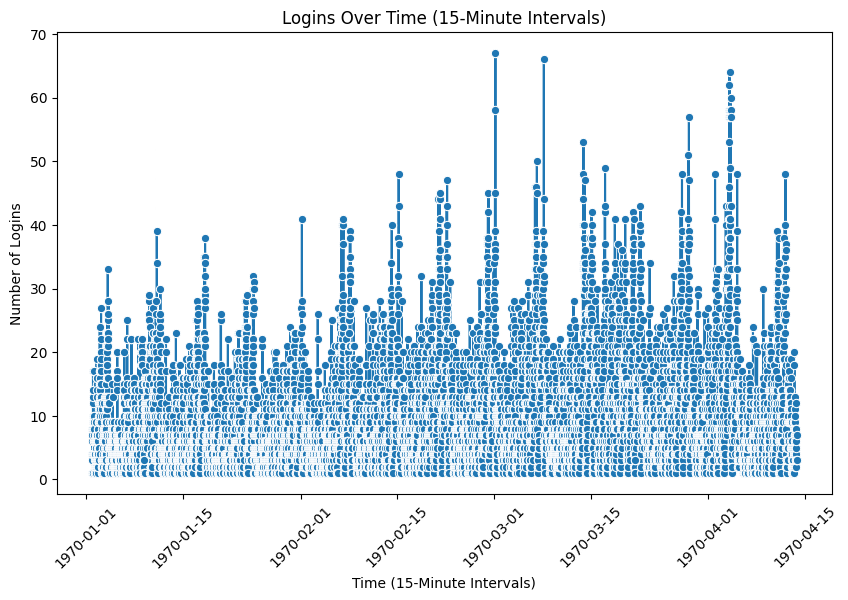

In [123]:
# Create the plot
fig, ax = plt.subplots(figsize=(10, 6))
sns.lineplot(data=logins_df1, x='login_time_rounded', y='total_logins', marker='o', ax=ax)
ax.set_title('Logins Over Time (15-Minute Intervals)')
ax.set_xlabel('Time (15-Minute Intervals)')
ax.set_ylabel('Number of Logins')
plt.xticks(rotation=45)
plt.show()

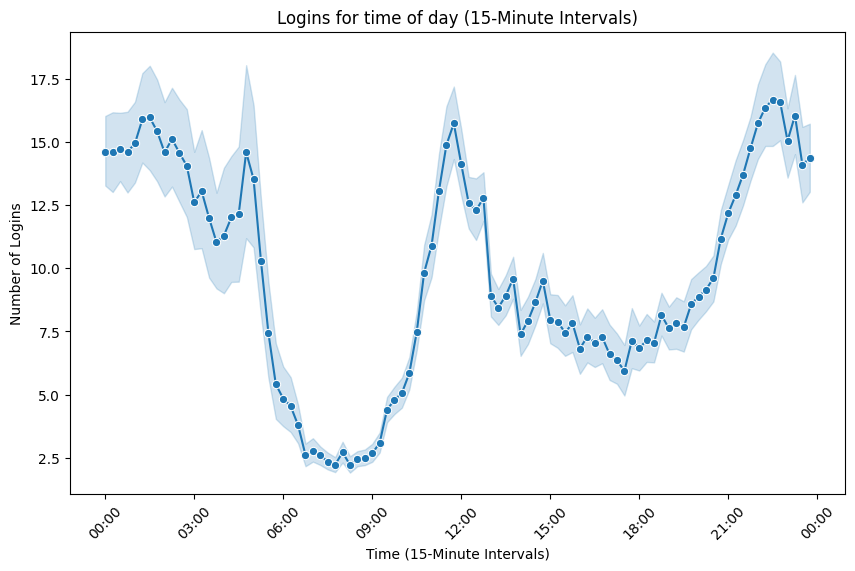

In [126]:
# Create the plot
fig, ax = plt.subplots(figsize=(10, 6))
sns.lineplot(data=logins_df1, x='time_of_day', y='total_logins', marker='o', ax=ax)
# Create the formatter for the x-axis to show only time
time_format = mdates.DateFormatter('%H:%M')
ax.xaxis.set_major_formatter(time_format)
ax.set_title('Logins for time of day (15-Minute Intervals)')
ax.set_xlabel('Time (15-Minute Intervals)')
ax.set_ylabel('Number of Logins')
plt.xticks(rotation=45)
plt.show()

Comparing the daily login times we can see that most logins happen at night from 2100 to 0500. 

There are minimal logins from 0600 to 1000.
from 11 to 1300 logins peak.
1300 to 2100 the logins stay steady through the afternoon and evening.

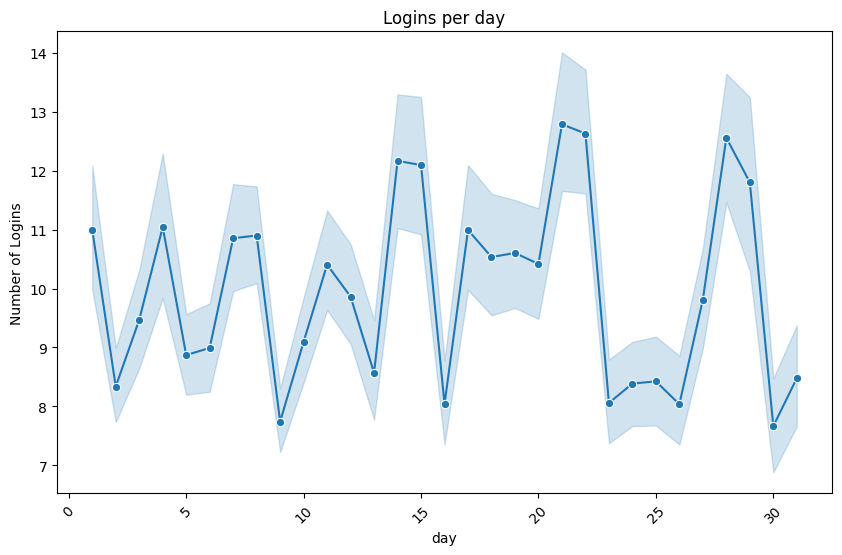

In [106]:
# Create the plot
fig, ax = plt.subplots(figsize=(10, 6))
sns.lineplot(data=logins_df1, x='day', y='total_logins', marker='o', ax=ax)
ax.set_title('Logins per day')
ax.set_xlabel('day')
ax.set_ylabel('Number of Logins')
plt.xticks(rotation=45)
plt.show()

Comparing day logins across the 4 months, we see that logins fluctuate through the month. However. we can see that as the month progresses the amplitude of logins increases at the end of the month when compared to the beginging of the month

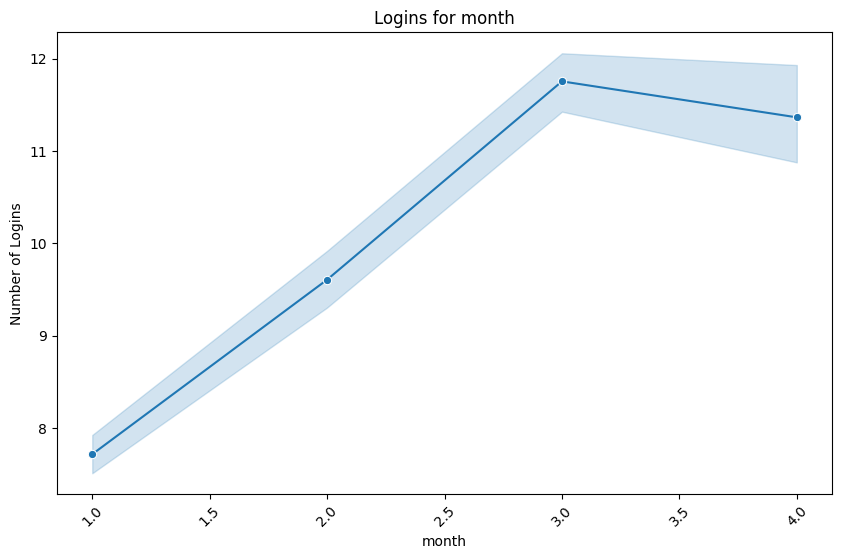

In [111]:
# Create the plot
fig, ax = plt.subplots(figsize=(10, 6))
sns.lineplot(data=logins_df1, x='month', y='total_logins', marker='o', ax=ax)
ax.set_title('Logins for month')
ax.set_xlabel('month')
ax.set_ylabel('Number of Logins')
plt.xticks(rotation=45)
plt.show()

We can see that at the end of the quater logins increase from the first to third month. The logins then stay the same from the 3rd to 4th month.

There are many time stamps to see on one graph. However if we break down the time stamps by time, day, month, and year, we get obvious patterns that are easy to view. The main ones are that there are more logins are increased at night, 1200, the end of the month, and the end of the quater.

______________________________________________________

##### Part 2 - Expermient and Metircs Design
______________________________________________________

The neighboring cities of Gotham and Metropolis have complementary circadian rhythms: on weekdays, Ultimate Gotham is most active at night, and Ultimate Metropolis is most active during the day. On weekends, there is reasonable activity in both cities.

However, a toll bridge, with a two way toll, between the two cities causes driver partners to tend to be exclusive to each city. The Ultimate managers of city operations for the two cities have proposed an experiment to encourage driver partners to be available in both cities, by reimbursing all toll costs.

1) What would you choose as the key measure of success of this experiment in encouraging driver partners to serve both cities, and why would you choose this metric?

Gotham is active at night, and Metropolis is active in the day, but both are equally active on the weekends.

I think a successful indicator would be weekend activity levels at the toll booth on weekdays. This would show that drivers are crossing into the opposite city during all hours.

I assume that drivers cross on the weekend because both cities have weekend days and night life for business.

Another indicator would be what city the drivers are coming from. If drivers cross from Gotham to Metropolis in the morning and vice versa at night, it indicates that drivers are taking advantage of the incentive. The drivers could also be registered by their home city to better see which direction the drivers are crossing the bridge.


2) Describe a practical experiment you would design to compare the effectiveness of the proposed change in relation to the key measure of success. Please provide details on:

a) how you will implement the experiment.

Data will be collected from the Gotham and Metropolis toll booths at either side of the bridge. The data will include the datetime of when they passed the booth and drivers hometown/car registration. 

The drivers who use the incentive will also need to register with their license plate information in order to get reimbursed. If possible, drivers will get a sticker, or fast pass type of card to track their bridge traffic so they don't have to wait in line at the toll booth and can use a special lane as well.

b) what statistical test(s) you will conduct to verify the significance of the observation.

I will measure bridge traffic before the incentive is implemented and compare it to bridge traffic after the reimbursement starts. Then the number of cars crossing the bridge based on the datetime will be evaluated to see if traffic has increased. A t-test will measure if the before and after values are statistically different using a p value of < 0.05.

c) how you would interpret the results and provide recommendations to the city operations team along with any caveats.

If the traffic is significantly different based on a p value of 0.05 when comparing the datetime traffic data of before and after the incentive, it means the experiment was successful. This means that Ultimate should continue reimbursing or subsidizing bridge toll costs to encourage their drivers to be available in both cities.

Ultimate should also survey their drivers to see if the drivers would continue working in both cities if there was no longer an incentive along with other questions about the driver’s work experience with Ultimate.
